# Tutorial 14 - Simple memoryless model

Compare a simple GLM and a small 2-layer NN

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import nems
from nems import Model
from nems.layers import WeightChannels, FiniteImpulseResponse, RectifiedLinear, STRF
from nems import visualization
from nems.metrics import correlation
from nems.models.LN import LN_plot_strf


#  Synthesize some data 

Model has a linear term and 2nd-order polynomial term

r = s(8) + s(3)*s(5) + noise

In [2]:
# T x N (time x input channels)
cellid="Dummy"
input_fit = np.random.randn(10000,18)
input_test = np.random.randn(1000,18)

def gen_resp(s):
    r1 = s[:,[8]]
    r1[r1<0]=0
    r2 = s[:,[3]]*s[:,[5]]*3
    r2[r2<0]=0
    r = r1+r2+np.random.randn(s.shape[0],1)
    return r, r1, r2
    
response_fit, _, _ = gen_resp(input_fit)
response_test, r1, r2 = gen_resp(input_test)


# Intialize LN and simple NN models

In [3]:

ln_model = Model(name=f"{cellid}-GLM")
ln_model.add_layers(
    WeightChannels(shape=(18, 1)),  # 18 spectral channels->1 output
    RectifiedLinear(shape=(1,), no_shift=False, no_offset=False)  # static nonlinearity, 1 output
)

# Minimal-complexity two-layer network
n_banks=3
nn_model = Model(name=f"{cellid}-NN")
nn_model.add_layers(
    WeightChannels(shape=(18, n_banks)),  # 18 spectral channels->n_banks outputs
    RectifiedLinear(shape=(n_banks,)),  # static nonlinearity, n_bank output
    WeightChannels(shape=(n_banks, 1)),  # n_banks->1 output
    RectifiedLinear(shape=(1,), no_shift=False, no_offset=False)  # static nonlinearity, 1 output
)

# We can also see the additional dimension added to our input weight layer
# compared to how our simpler model is set up
print(f'''  LN input layer coefficient shape: {ln_model.layers[0].coefficients.shape}
  NN input layer coefficient shape: {nn_model.layers[0].coefficients.shape}''')


  LN input layer coefficient shape: (18, 1)
  NN input layer coefficient shape: (18, 3)


Verbose description of each model layer

In [4]:
nn_model

Model()
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
WeightChannels(shape=(18, 3), norm_coefficients=False)
Parameter(name=coefficients, shape=(18, 3))

RectifiedLinear(shape=(3,), normalize_output=False, no_shift=True, no_offset=True, no_gain=True)
Parameter(name=shift, shape=(3,))
----------------
Parameter(name=offset, shape=(3,))
----------------
Parameter(name=gain, shape=(3,))

WeightChannels(shape=(3, 1), norm_coefficients=False)
Parameter(name=coefficients, shape=(3, 1))

RectifiedLinear(shape=(1,), normalize_output=False, no_shift=False, no_offset=False, no_gain=True)
Parameter(name=shift, shape=(1,))
----------------
Parameter(name=offset, shape=(1,))
----------------
Parameter(name=gain, shape=(1,))
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Random initial parameter weights

In [5]:
#   sample_from_priors(): Randomizes model parameters

ln_model = ln_model.sample_from_priors()
nn_model = nn_model.sample_from_priors()


# Do the fits

In [6]:
# Basic options to quickly fit our models for tf backend
options = {'cost_function': 'squared_error', 
           'early_stopping_delay': 50, 'early_stopping_patience': 100,
           'early_stopping_tolerance': 1e-4, 'validation_split': 0,
           'learning_rate': 5e-3, 'epochs': 2000}

# Fit our models to sythesized data
# We use 'tf' backend to improve training speed.
fitted_ln = ln_model.fit(input_fit, response_fit, fitter_options=options, backend='tf')
fitted_nn = nn_model.fit(input_fit, response_fit, fitter_options=options, backend='tf')



2026-03-12 05:07:49.667047: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-12 05:07:49.791088: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-12 05:07:49.793213: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-12 05:07:49.796389: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

1 Physical GPUs, 1 Logical GPUs


[nems.backends.tf.backend INFO] Init loss: 0.950, tol: 0.0001, batch_size: None, shuffle: False
[nems.backends.tf.backend INFO] Epoch 0000/2000 - loss: 9.5019e-01
[nems.backends.tf.backend INFO] Epoch 0050/2000 - loss: 7.8187e-01
[nems.backends.tf.backend INFO] Epoch 0100/2000 - loss: 6.6621e-01
[nems.backends.tf.backend INFO] Epoch 0150/2000 - loss: 6.4182e-01
[nems.backends.tf.backend INFO] Epoch 0200/2000 - loss: 6.2639e-01
[nems.backends.tf.backend INFO] Epoch 0250/2000 - loss: 6.1282e-01
[nems.backends.tf.backend INFO] Epoch 0300/2000 - loss: 6.0114e-01
[nems.backends.tf.backend INFO] Epoch 0350/2000 - loss: 5.9152e-01
[nems.backends.tf.backend INFO] Epoch 0400/2000 - loss: 5.8361e-01
[nems.backends.tf.backend INFO] Epoch 0450/2000 - loss: 5.7719e-01
[nems.backends.tf.backend INFO] Epoch 0500/2000 - loss: 5.7170e-01
[nems.backends.tf.backend INFO] Epoch 0550/2000 - loss: 5.6700e-01
[nems.backends.tf.backend INFO] Epoch 0600/2000 - loss: 5.6288e-01
[nems.backends.tf.backend INFO] E

# Plot the model weights

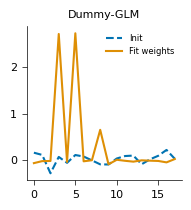

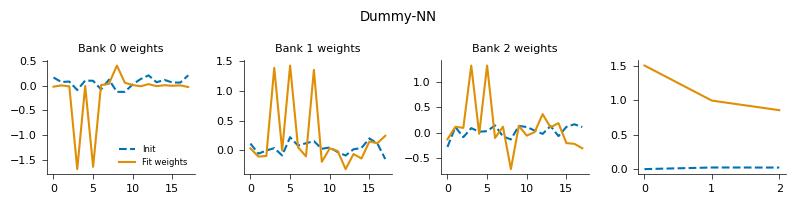

In [7]:
ln_parms0 = ln_model.get_parameter_values()
ln_parms = fitted_ln.get_parameter_values()
nn_parms0 = nn_model.get_parameter_values()
nn_parms = fitted_nn.get_parameter_values()

f,ax=plt.subplots(figsize=(2,2))
ax.plot(ln_parms0['WeightChannels']['coefficients'], '--', label='Init')
ax.plot(ln_parms['WeightChannels']['coefficients'], '-', label='Fit weights')
ax.set_title(f"{fitted_ln.name}")
ax.legend()

f,ax=plt.subplots(1,n_banks+1,figsize=(8,2))
for ic in range(n_banks):
    ax[ic].plot(nn_parms0['WeightChannels']['coefficients'][:,ic], '--', label='Init')
    ax[ic].plot(nn_parms['WeightChannels']['coefficients'][:,ic], '-', label='Fit weights')
    ax[ic].set_title(f"Bank {ic} weights")
ax[0].legend()
ax[-1].plot(nn_parms0['WeightChannels0']['coefficients'], '--', label='Init')
ax[-1].plot(nn_parms['WeightChannels0']['coefficients'], '-', label='Fit weights')
f.suptitle(f"{fitted_nn.name}")
f.tight_layout()


# Generate predictions

In [16]:
pred_ln = fitted_ln.predict(input_test)
pred_nn = fitted_nn.predict(input_test)

print(f"LN prediction correlation: {correlation(pred_ln,response_test):.3f}")
print(f"NN prediction correlation: {correlation(pred_nn,response_test):.3f}")


LN prediction correlation: 0.577
NN prediction correlation: 0.798


Compare the model predictions to the linear (r1) and 2nd-order (r2) components of the actual response
in the test data


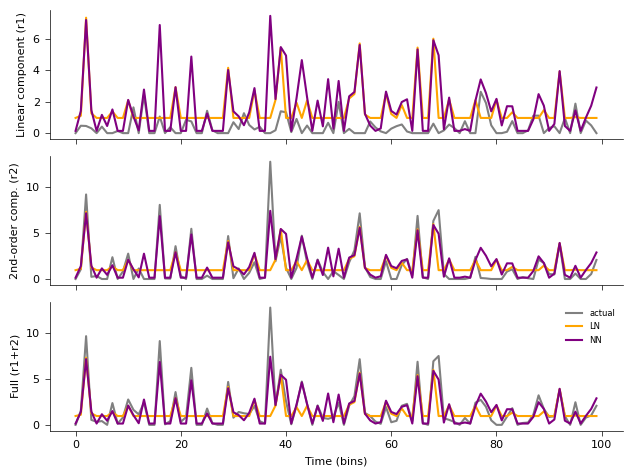

In [9]:
f,ax=plt.subplots(3,1, sharex=True)

T=100
ax[0].plot(r1[:T],color='gray')
ax[0].plot(pred_ln[:T],color='orange')
ax[0].plot(pred_nn[:T],color='purple')
ax[0].set_ylabel('Linear component (r1)')

ax[1].plot(r2[:T],color='gray')
ax[1].plot(pred_ln[:T],color='orange')
ax[1].plot(pred_nn[:T],color='purple')
ax[1].set_ylabel('2nd-order comp. (r2)')

ax[2].plot(r1[:T]+r2[:T],color='gray', label='actual')
ax[2].plot(pred_ln[:T],color='orange', label='LN')
ax[2].plot(pred_nn[:T],color='purple', label='NN')
ax[2].set_ylabel('Full (r1+r2)')
ax[2].set_xlabel('Time (bins)')
ax[2].legend()
plt.tight_layout();


# Some built-in plots

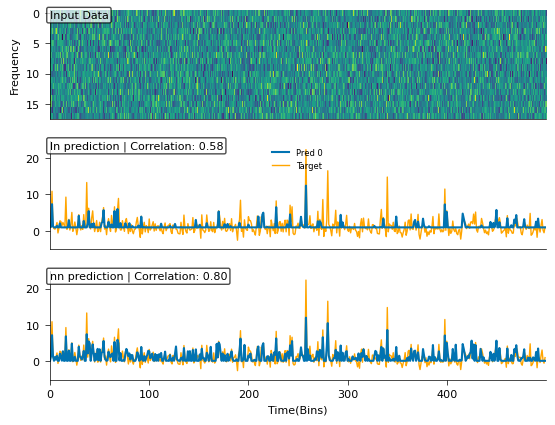

In [10]:
visualization.plot_predictions({'ln prediction':pred_ln, 'nn prediction':pred_nn},
                               input_test, response_test, correlation=True);


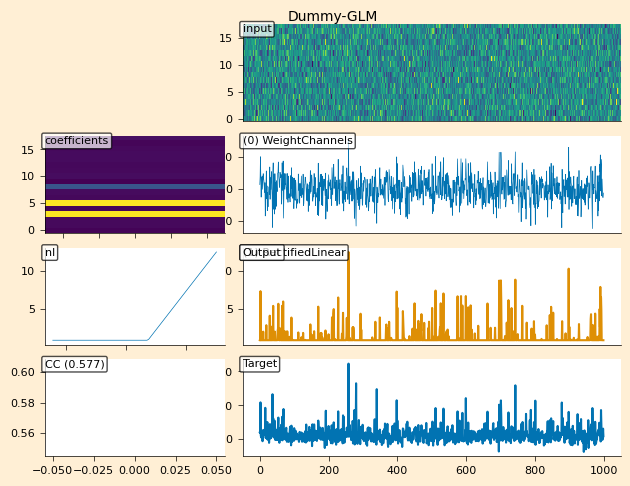

In [13]:
# Plotting our Models after fits
f=fitted_ln.plot(input_test, target=response_test, figure_kwargs={'facecolor': 'papayawhip'})


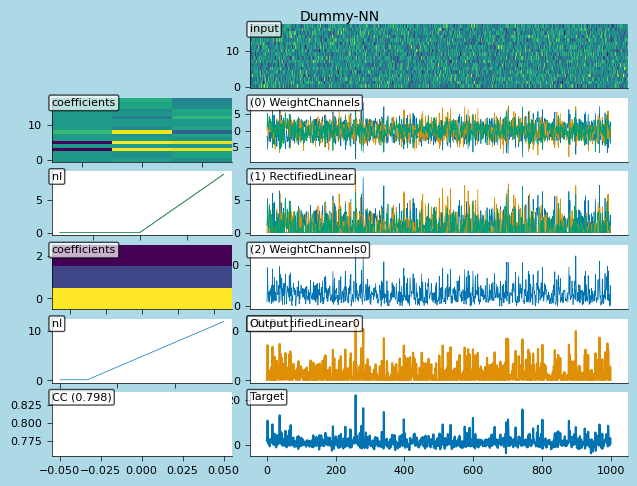

In [14]:
f=fitted_nn.plot(input_test, target=response_test, figure_kwargs={'facecolor': 'lightblue'})
